In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.discriminant_analysis import StandardScaler
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [36]:
# Define home directory
home_dir = '/zhome/d0/a/221493/thesis/'
data_dir = home_dir + 'data/'

In [37]:
DISEASE = 'cardiomegaly'

## Assess the Baseline C0 Model
> densenet121-res224-chex

### Train and Validation sets 
- Included path, probability by C0, true label, correctness score (1 if C0 was right), and margin

In [38]:
# Load baseline predicitons by C0 for Pleural Effusion

train_c0 = pd.read_csv(home_dir + f'results/C0_baseline/{DISEASE}/train_c0_{DISEASE}.csv')
train_c0.head()

,path,prob,true,pred,correct,margin
0,CheXpert-v1.0-small/train/patient00001/study1/...,0.575085,0.0,0,1,0.054625
1,CheXpert-v1.0-small/train/patient00004/study1/...,0.527057,0.0,0,1,0.102654
2,CheXpert-v1.0-small/train/patient00005/study1/...,0.529270,0.0,0,1,0.100441
3,CheXpert-v1.0-small/train/patient00006/study1/...,0.579547,0.0,0,1,0.050163
4,CheXpert-v1.0-small/train/patient00010/study1/...,0.501950,0.0,0,1,0.127760


In [39]:

valid_c0 = pd.read_csv(home_dir + f'results/C0_baseline/{DISEASE}/valid_c0_{DISEASE}.csv')
valid_c0.head()

,path,prob,true,pred,correct,margin
0,CheXpert-v1.0-small/valid/patient64541/study1/...,0.656356,0.0,1,0,0.026646
1,CheXpert-v1.0-small/valid/patient64542/study1/...,0.505334,0.0,0,1,0.124376
2,CheXpert-v1.0-small/valid/patient64543/study1/...,0.676212,0.0,1,0,0.046501
3,CheXpert-v1.0-small/valid/patient64544/study1/...,0.504037,0.0,0,1,0.125673
4,CheXpert-v1.0-small/valid/patient64545/study1/...,0.616840,0.0,0,1,0.012871


Class distribution in training set:
true
0.0    18105
1.0     4674
Name: count, dtype: int64

Class distribution in validation set:
true
0.0    194
1.0      8
Name: count, dtype: int64



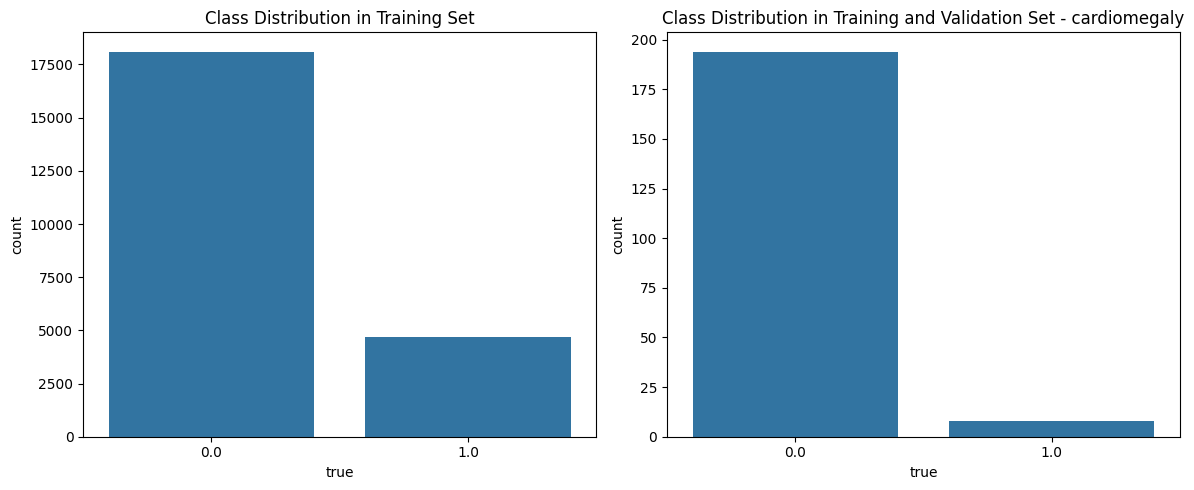

In [40]:
# Plot frequency of classes in train and validation set
print(f'Class distribution in training set:\n{train_c0["true"].value_counts()}\n')
print(f'Class distribution in validation set:\n{valid_c0["true"].value_counts()}\n')
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='true', data=train_c0)
plt.title('Class Distribution in Training Set')
plt.subplot(1, 2, 2)
sns.countplot(x='true', data=valid_c0)
plt.title(f'Class Distribution in Validation Set')
plt.tight_layout()
plt.title(f'Class Distribution in Training and Validation Set - {DISEASE}')
plt.show()

### Summary of C0's performance on Effusion

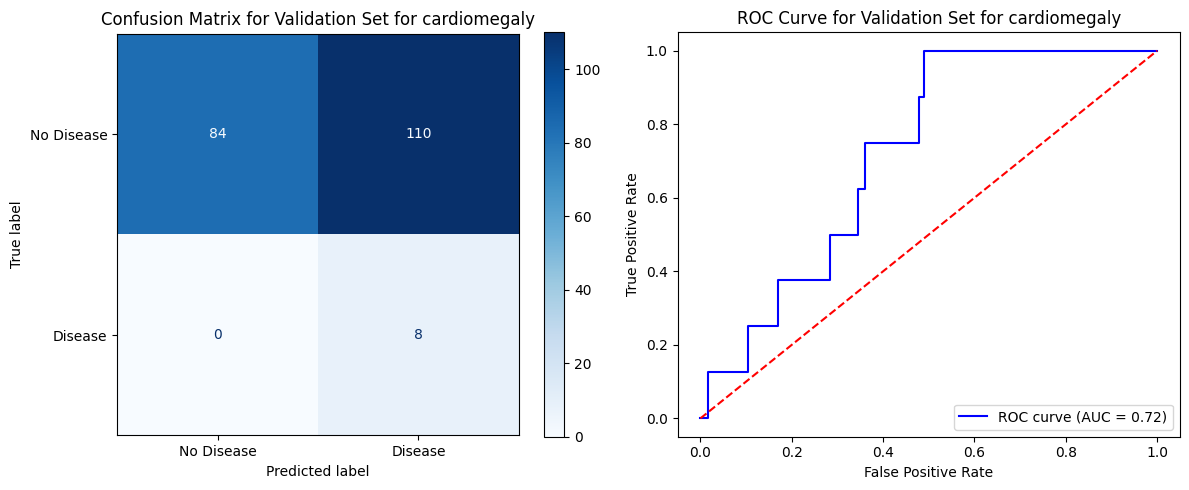

In [41]:
# Confusion matrix for validation set and ROC curve side by side
# Start with confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc    
y_true = valid_c0['true']
y_pred = valid_c0['pred']
y_prob = valid_c0['prob']
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Confusion Matrix for Validation Set for {DISEASE}')
# Now ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Validation Set for {DISEASE}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

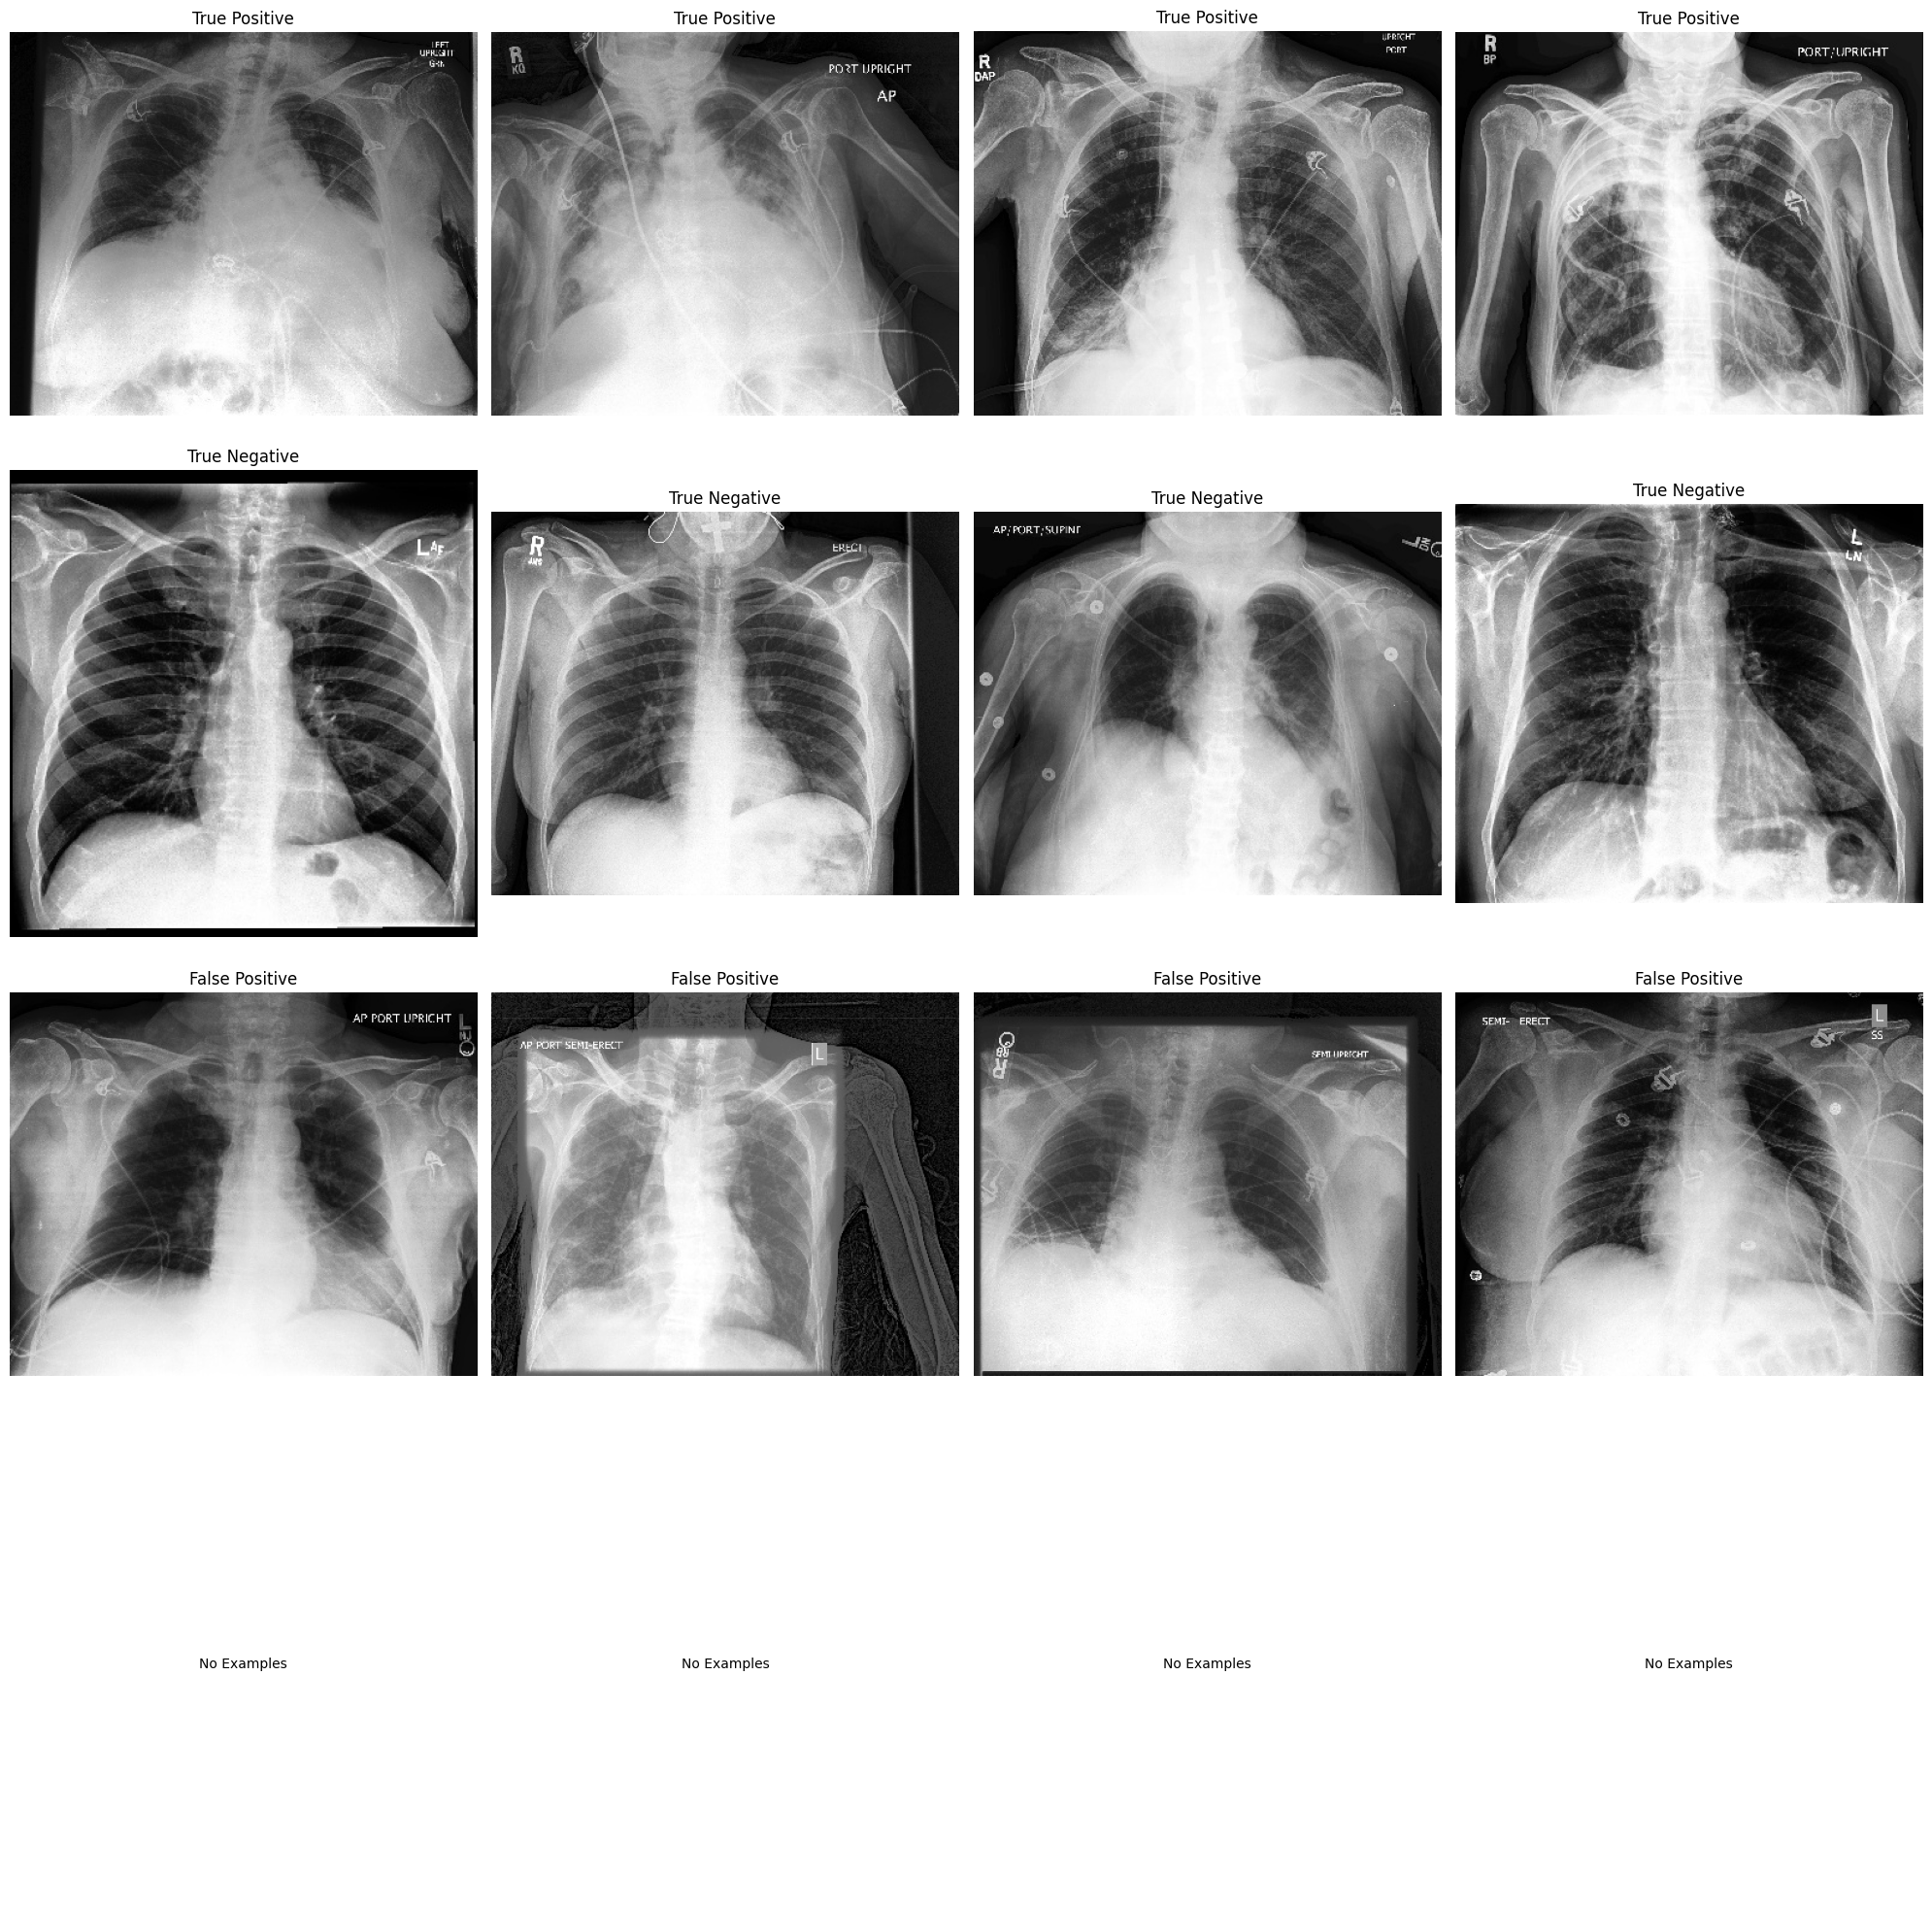

In [42]:
scenarios = {
    'True Positive':  [valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 1)].iloc[i]['path'] for i in range(min(4, len(valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 1)])))],
    'True Negative':  [valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 0)].iloc[i]['path'] for i in range(min(4, len(valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 0)])))],
    'False Positive': [valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 1)].iloc[i]['path'] for i in range(min(4, len(valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 1)])))],
    'False Negative': [valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 0)].iloc[i]['path'] for i in range(min(4, len(valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 0)])))],
}

plt.figure(figsize=(20, 20))
for row, (title, examples) in enumerate(scenarios.items()):
    for col in range(4):
        plt.subplot(4, 4, row * 4 + col + 1)
        if col < len(examples):
            plt.imshow(plt.imread(data_dir + examples[col]), cmap='gray')
            plt.title(title)
        else:
            plt.text(0.5, 0.5, 'No Examples', ha='center', va='center', transform=plt.gca().transAxes)
        plt.axis('off')
plt.tight_layout()
plt.show()


In [43]:
# Analyse the error made by the model, by looking at the false positives and false negatives.
# Print number of false positives and false negatives
num_true_positives = len(valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 1)])
num_true_negatives = len(valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 0)])
num_false_positives = len(valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 1)])
num_false_negatives = len(valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 0)])
print(f'Number of True Positives: {num_true_positives}')
print(f'Number of True Negatives: {num_true_negatives}')
print(f'Number of False Positives: {num_false_positives}')
print(f'Number of False Negatives: {num_false_negatives}')

Number of True Positives: 8
Number of True Negatives: 84
Number of False Positives: 110
Number of False Negatives: 0


## Baseline - Can we train C2 (a quality control model) using only the probs by C0? 
- Will it accurately determine correct and wrong predictions?

In [44]:
# C2 will use [PROB] as its only feature and [CORRECT] as its target, where [CORRECT] is 1 if the prediction is correct and 0 if it is incorrect. 
# Create a new dataframe for C2 with these columns.
c2_train_df = pd.DataFrame()
c2_train_df['PROB'] = train_c0['prob']
c2_train_df['CORRECT'] = (train_c0['true'] == train_c0['pred']).astype(int)

c2_valid_df = pd.DataFrame()
c2_valid_df['PROB'] = valid_c0['prob']
c2_valid_df['CORRECT'] = (valid_c0['true'] == valid_c0['pred']).astype(int)   

In [45]:
c2_train_df

,PROB,CORRECT
0,0.575085,1
1,0.527057,1
2,0.529270,1
3,0.579547,1
4,0.501950,1
...,...,...
22774,0.533435,1
22775,0.501037,1
22776,0.514269,1
22777,0.566249,1


In [46]:
c2_valid_df

,PROB,CORRECT
0,0.656356,0
1,0.505334,1
2,0.676212,0
3,0.504037,1
4,0.616840,1
...,...,...
197,0.688297,0
198,0.565474,1
199,0.702218,0
200,0.685088,0


In [47]:
# Train a simple logistic regression model for C2 using PROB as the only feature and CORRECT as the target. Evaluate the model on the validation set and print the accuracy, precision, recall, and F1 score.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
X_train = c2_train_df[['PROB']]
y_train = c2_train_df['CORRECT']
X_valid = c2_valid_df[['PROB']]
y_valid = c2_valid_df['CORRECT']
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [48]:
y_pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Accuracy: 0.80
Precision: 0.71
Recall: 0.93
F1 Score: 0.81


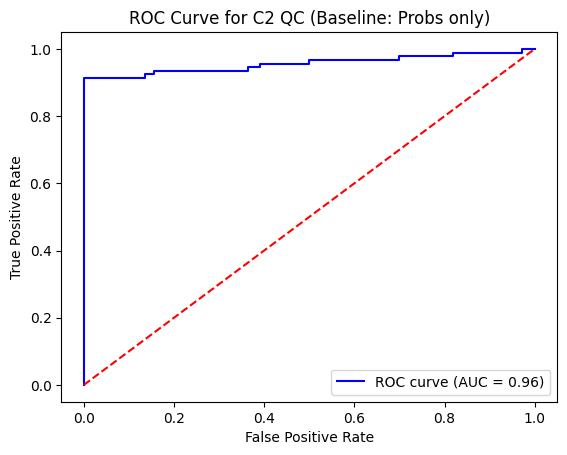

In [49]:
# ROC curve for C2
y_prob = model.predict_proba(X_valid)[:, 1]
fpr, tpr, _ = roc_curve(y_valid, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for C2 QC (Baseline: Probs only)')
plt.legend(loc='lower right')
plt.show()

# 1st Simplified Attempt - Is there information in the counterfactual changes?
- We fake counterfactual samples
     - We take our sample, and our counterfactual is the other closest sample that has a flipped prediction
- And determine the difference in atributes between the counterfactual and the original image (delta-A)
- Then train C2 using [delta-A] as Feature and [CORRECT] as target

In [50]:
# Load the C1 (attribute vectors) for training and validation set

c1_train_df = pd.read_csv(home_dir + f'results/C1_attributes/train_c1_attribute_vector.csv')
c1_valid_df = pd.read_csv(home_dir + f'results/C1_attributes/valid_c1_attribute_vector.csv')


In [51]:
# Merge the baseline predictions with the attribute vectors by path
train_c2 = train_c0.merge(c1_train_df, on='path', how='left')
valid_c2 = valid_c0.merge(c1_valid_df, on='path', how='left')
train_c2

,path,prob,true,pred,correct,margin,patient_id,age_pred,sex_male,sex_female,...,Right Hilus Pulmonis_area_pixels,Right Hilus Pulmonis_bbox_width,Right Hilus Pulmonis_bbox_height,Right Hilus Pulmonis_bbox_ratio,Right Hilus Pulmonis_perimeter,Aorta_area_pixels,Aorta_bbox_width,Aorta_bbox_height,Aorta_bbox_ratio,Aorta_perimeter
0,CheXpert-v1.0-small/train/patient00001/study1/...,0.575085,0.0,0,1,0.054625,patient00001,46.296631,7.792770e-07,0.999999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CheXpert-v1.0-small/train/patient00004/study1/...,0.527057,0.0,0,1,0.102654,patient00004,26.006752,3.213766e-03,0.996786,...,3625.0,51.0,129.0,0.395349,310.208150,2958.0,38.0,97.0,3.917526e-01,235.681239
2,CheXpert-v1.0-small/train/patient00005/study1/...,0.529270,0.0,0,1,0.100441,patient00005,41.602314,9.999933e-01,0.000007,...,2209.0,38.0,92.0,0.413043,223.681239,1585.0,40.0,57.0,7.017544e-01,159.438598
3,CheXpert-v1.0-small/train/patient00006/study1/...,0.579547,0.0,0,1,0.050163,patient00006,51.069099,3.701182e-01,0.629882,...,6660.0,74.0,146.0,0.506849,399.462984,5355.0,71.0,96.0,7.395833e-01,286.208151
4,CheXpert-v1.0-small/train/patient00010/study1/...,0.501950,0.0,0,1,0.127760,patient00010,56.875008,1.270073e-06,0.999999,...,3888.0,56.0,109.0,0.513761,282.450791,3147.0,49.0,83.0,5.903614e-01,221.823375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22774,CheXpert-v1.0-small/train/patient64520/study1/...,0.533435,0.0,0,1,0.096275,patient64520,61.064758,1.841805e-05,0.999981,...,4073.0,63.0,84.0,0.750000,254.894442,5178.0,74.0,92.0,8.043478e-01,281.622364
22775,CheXpert-v1.0-small/train/patient64522/study1/...,0.501037,0.0,0,1,0.128674,patient64522,25.601467,6.192619e-08,1.000000,...,3350.0,49.0,122.0,0.401639,293.379723,3645.0,53.0,101.0,5.247525e-01,259.379723
22776,CheXpert-v1.0-small/train/patient64532/study1/...,0.514269,0.0,0,1,0.115441,patient64532,50.757626,2.449746e-03,0.997550,...,2256.0,49.0,66.0,0.742424,184.308656,3.0,2.0,0.0,2.000000e+06,4.000000
22777,CheXpert-v1.0-small/train/patient64537/study1/...,0.566249,0.0,0,1,0.063461,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
def add_clinical_ratios(df):
    df = df.copy()
    
    # Cardiothoracic ratio — most important for cardiomegaly
    # Normal < 0.5, enlarged heart > 0.5
    df['cardiothoracic_ratio'] = df['Heart_bbox_width'] / (df['Left Lung_bbox_width'] + df['Right Lung_bbox_width'])
    
    # Lung symmetry — asymmetry can indicate effusion or pneumothorax
    df['lung_area_ratio']      = df['Left Lung_area_pixels'] / (df['Right Lung_area_pixels'] + 1e-6)
    df['lung_height_ratio']    = df['Left Lung_bbox_height'] / (df['Right Lung_bbox_height'] + 1e-6)
    df['lung_width_ratio']     = df['Left Lung_bbox_width']  / (df['Right Lung_bbox_width']  + 1e-6)
    
    # Lung area relative to total image area — captures hyperinflation/collapse
    total_area = df['Left Lung_area_pixels'] + df['Right Lung_area_pixels']
    df['left_lung_fraction']   = df['Left Lung_area_pixels']  / (total_area + 1e-6)
    df['right_lung_fraction']  = df['Right Lung_area_pixels'] / (total_area + 1e-6)
    
    # Mediastinal width relative to lung width — widens in effusion/cardiomegaly
    df['mediastinal_ratio']    = df['Mediastinum_bbox_width'] / (df['Left Lung_bbox_width'] + df['Right Lung_bbox_width'] + 1e-6)

    return df

In [53]:
DISEASE_PREFIXES = {
    'effusion':     ["Left Lung", "Right Lung", "Facies Diaphragmatica",
                     "Left Hilus Pulmonis", "Right Hilus Pulmonis", "Mediastinum"],
    'pneumothorax': ["Left Lung", "Right Lung", "Mediastinum"],
    'cardiomegaly': ["Heart", "Aorta", "Mediastinum"],
    'atelectasis':  ["Left Lung", "Right Lung", "Facies Diaphragmatica",
                     "Left Hilus Pulmonis", "Right Hilus Pulmonis", "Mediastinum", "Heart"],
}

DISEASE_RATIO_COLS = {
    'effusion':     ['lung_area_ratio', 'lung_height_ratio', 'lung_width_ratio',
                     'left_lung_fraction', 'right_lung_fraction', 'mediastinal_ratio'],
    'pneumothorax': ['lung_area_ratio', 'lung_height_ratio', 'lung_width_ratio',
                     'left_lung_fraction', 'right_lung_fraction', 'mediastinal_ratio'],
    'cardiomegaly': ['cardiothoracic_ratio', 'mediastinal_ratio'],
    'atelectasis':  ['lung_area_ratio', 'lung_height_ratio', 'lung_width_ratio',
                     'left_lung_fraction', 'right_lung_fraction', 'mediastinal_ratio'],
}

pixel_cols = [
    col for col in train_c2.columns
    if any(col.lower().startswith(p.lower()) for p in DISEASE_PREFIXES[DISEASE])]


In [54]:
# Add clinical ratios — must be before cols_to_keep selection
train_c2 = add_clinical_ratios(train_c2)
valid_c2 = add_clinical_ratios(valid_c2)

relevant_columns = DISEASE_RATIO_COLS[DISEASE] + pixel_cols

cols_to_keep = ["path", "prob", "true", "pred", "correct", "patient_id"] + relevant_columns

train_filtered = train_c2[cols_to_keep].dropna(subset=relevant_columns).copy()  # ✅
valid_filtered = valid_c2[cols_to_keep].dropna(subset=relevant_columns).copy()  # ✅

attr_scaler = StandardScaler()
train_filtered[relevant_columns] = attr_scaler.fit_transform(train_filtered[relevant_columns].values.astype(float))
valid_filtered[relevant_columns] = attr_scaler.transform(valid_filtered[relevant_columns].values.astype(float))

print(f"Disease        : {DISEASE}")
print(f"Ratio columns  : {DISEASE_RATIO_COLS[DISEASE]}")
print(f"Pixel columns  : {pixel_cols}")
print(f"Total features : {len(relevant_columns)}")
print(f"Shape — train  : {train_filtered.shape}  valid: {valid_filtered.shape}")

Disease        : cardiomegaly
Ratio columns  : ['cardiothoracic_ratio', 'mediastinal_ratio']
Pixel columns  : ['Heart_area_pixels', 'Heart_bbox_width', 'Heart_bbox_height', 'Heart_bbox_ratio', 'Heart_perimeter', 'Mediastinum_area_pixels', 'Mediastinum_bbox_width', 'Mediastinum_bbox_height', 'Mediastinum_bbox_ratio', 'Mediastinum_perimeter', 'Aorta_area_pixels', 'Aorta_bbox_width', 'Aorta_bbox_height', 'Aorta_bbox_ratio', 'Aorta_perimeter']
Total features : 17
Shape — train  : (11975, 23)  valid: (183, 23)


In [55]:
train_filtered

,path,prob,true,pred,correct,patient_id,cardiothoracic_ratio,mediastinal_ratio,Heart_area_pixels,Heart_bbox_width,...,Mediastinum_area_pixels,Mediastinum_bbox_width,Mediastinum_bbox_height,Mediastinum_bbox_ratio,Mediastinum_perimeter,Aorta_area_pixels,Aorta_bbox_width,Aorta_bbox_height,Aorta_bbox_ratio,Aorta_perimeter
1,CheXpert-v1.0-small/train/patient00004/study1/...,0.527057,0.0,0,1,patient00004,-0.588926,-0.702146,0.202772,-0.471385,...,-0.585012,-0.690185,-0.159598,-0.485772,-0.356324,-0.064987,-0.840522,0.858059,-0.012275,0.328347
2,CheXpert-v1.0-small/train/patient00005/study1/...,0.529270,0.0,0,1,patient00005,-0.677633,0.273628,0.284328,-0.212898,...,-0.478307,0.912403,-0.766311,1.386144,-0.159366,-1.088546,-0.703685,-0.906055,-0.012260,-0.900388
3,CheXpert-v1.0-small/train/patient00006/study1/...,0.579547,0.0,0,1,patient00006,0.100402,-0.400651,1.752997,0.710269,...,0.706674,0.237629,0.661249,-0.449112,0.698472,1.721954,1.417289,0.813956,-0.012258,1.142643
4,CheXpert-v1.0-small/train/patient00010/study1/...,0.501950,0.0,0,1,patient00010,-0.728648,-0.543472,0.054469,0.156369,...,0.159673,0.406322,-0.195287,0.374520,0.094092,0.075911,-0.087918,0.240619,-0.012265,0.105012
5,CheXpert-v1.0-small/train/patient00012/study3/...,0.549464,0.0,0,1,patient00012,-0.241978,-0.068617,-0.831153,0.082515,...,-0.398185,0.321976,-0.766311,0.894459,-0.332675,-0.443696,-0.498429,-0.420923,-0.012263,-0.379142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22772,CheXpert-v1.0-small/train/patient64517/study1/...,0.501684,0.0,0,1,patient64517,-0.676149,-0.580940,-0.572561,-1.172991,...,-0.598116,-1.280612,0.340048,-1.270694,-0.134876,0.370380,0.322593,0.372928,-0.012263,0.380131
22773,CheXpert-v1.0-small/train/patient64519/study1/...,0.625106,0.0,0,1,patient64519,0.825930,1.519495,-1.312973,-0.692945,...,-0.851211,-0.099758,-0.659244,0.431547,-0.688496,-0.660634,0.254174,-1.082466,-0.012244,-0.521422
22774,CheXpert-v1.0-small/train/patient64520/study1/...,0.533435,0.0,0,1,patient64520,0.281269,1.772468,-0.189315,-0.139045,...,1.169060,1.502830,0.804005,0.280277,0.788764,1.590002,1.622544,0.637545,-0.012255,1.068738
22775,CheXpert-v1.0-small/train/patient64522/study1/...,0.501037,0.0,0,1,patient64522,-0.529547,0.503325,0.666248,-0.582165,...,0.620187,0.490669,0.768316,-0.357941,0.727019,0.447165,0.185756,1.034470,-0.012269,0.710274


In [ ]:
# Plot the distribution  of positives 

## Assess the Baseline C0 Model
> densenet121-res224-chex

### Calculate the mean attribute vector for each class and select most representative attributes

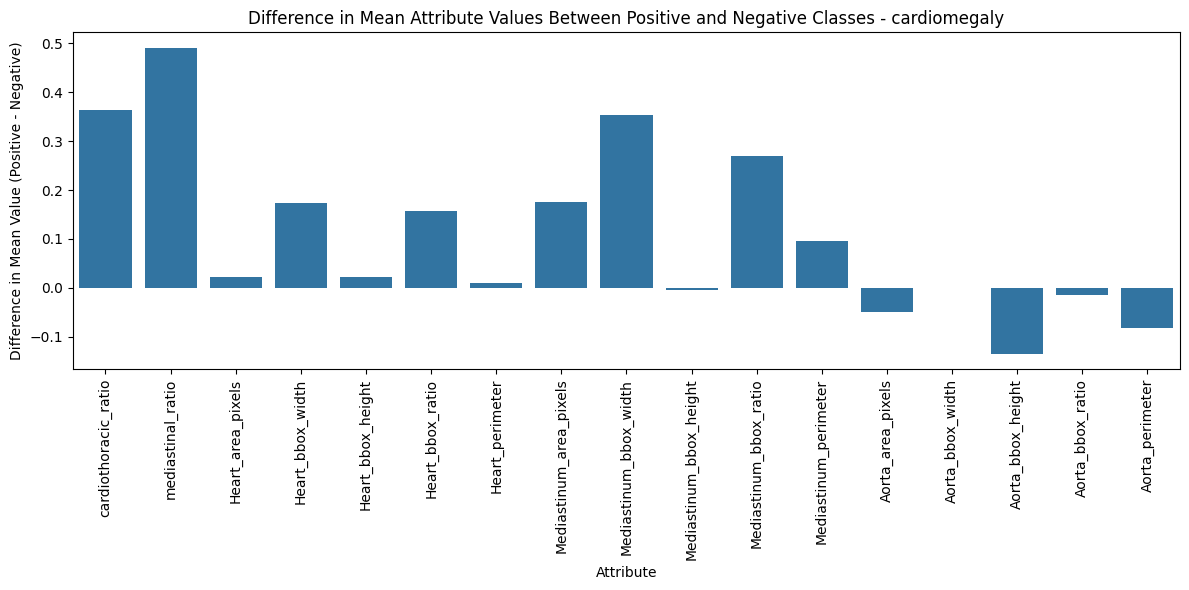

In [56]:
# Calculate the mean attribute vector for the positive and negative classes
disease_positive_mean = train_filtered[train_filtered['true'] == 1][relevant_columns].mean()
disease_negative_mean = train_filtered[train_filtered['true'] == 0][relevant_columns].mean()
difference = disease_positive_mean - disease_negative_mean

plt.figure(figsize=(12, 6))
sns.barplot(x=difference.index, y=difference.values)
plt.xticks(rotation=90)
plt.title(f'Difference in Mean Attribute Values Between Positive and Negative Classes - {DISEASE}')
plt.xlabel('Attribute')
plt.ylabel('Difference in Mean Value (Positive - Negative)')
plt.tight_layout()
plt.show()



## Now create the fake counterfactual for each image
#### THEORY: What is a fake counterfactual?
- A real counterfactual for sample i would be: the minimally different IMAGE that flips C0's prediction. We can't generate that yet (requires diffusion).
- Instead, we SIMULATE it by asking:
    - "What is the nearest training sample that C0 predicted with the OPPOSITE label?"

- KEY CHOICE: We use C0's PREDICTION (pred), NOT the ground truth (true).
- Why? Because we are probing C0's behaviour, not the disease severity.
- A real counterfactual flips C0's decision — so our fake CF must too.


In [74]:
# Split train into two pools based on C0's PREDICTION (not ground truth)
train_pred1 = train_filtered[train_filtered['pred'] == 1]
train_pred0 = train_filtered[train_filtered['pred'] == 0]

print(f"Training pool — C0 predicted positive (pred=1): {len(train_pred1):,}")
print(f"Training pool — C0 predicted negative (pred=0): {len(train_pred0):,}")
print("For a pred=1 sample → search in pred=0 pool (and vice versa).")


Training pool — C0 predicted positive (pred=1): 3,017
Training pool — C0 predicted negative (pred=0): 8,958
For a pred=1 sample → search in pred=0 pool (and vice versa).


In [75]:
# We want the MINIMAL change — just like real counterfactuals are constrained to be minimally different from the original. 
# The nearest neighbour in attribute space gives us the closest point on the opposite side of C0's decision boundary, which is our best proxy for "what would minimally flip this prediction".

# Fit two NN indices — one per prediction class — on the relevant (scaled) Lung attributes
nn_pred1 = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
nn_pred1.fit(train_pred1[relevant_columns].values)

nn_pred0 = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
nn_pred0.fit(train_pred0[relevant_columns].values)

print("NN indices built on scaled Lung attributes using (Euclidean) distance.")
print("Euclidean distance treats all attribute deviations equally — robust to outliers.")


NN indices built on scaled Lung attributes using (Euclidean) distance.
Euclidean distance treats all attribute deviations equally — robust to outliers.


### Calculate the change profiles
- For each sample, we "generate its fake CF" by finding its closest opposite neighbour, and calculate their delta-A

In [76]:

def compute_diff_vectors(df, nn_pred1, nn_pred0, train_pred1, train_pred0, relevant_columns):
    query         = df[relevant_columns].values
    query_preds   = df['pred'].values.astype(int)
    diff_vecs     = np.empty((len(df), len(relevant_columns)), dtype=np.float64)

    mask1 = query_preds == 1
    mask0 = ~mask1

    if mask1.any():
        _, idxs      = nn_pred0.kneighbors(query[mask1])
        neighbours   = train_pred0[relevant_columns].values[idxs[:, 0]]
        diff_vecs[mask1] = query[mask1] - neighbours

    if mask0.any():
        _, idxs      = nn_pred1.kneighbors(query[mask0])
        neighbours   = train_pred1[relevant_columns].values[idxs[:, 0]]
        diff_vecs[mask0] = query[mask0] - neighbours

    return diff_vecs

train_diff = compute_diff_vectors(train_filtered, nn_pred1, nn_pred0, train_pred1, train_pred0, relevant_columns)
valid_diff = compute_diff_vectors(valid_filtered, nn_pred1, nn_pred0, train_pred1, train_pred0, relevant_columns)

diff_col_names = [f"delta_{c}" for c in relevant_columns]
print(f"ΔA shape — train: {train_diff.shape}  valid: {valid_diff.shape}") # -> FOR EACH ROW, THERES A DIFFERENCE VECTOR, ON HOW MUCH EACH ATTRIBUTE CHANGED BETWEEN THE SAMPLE AND ITS FAKE COUNTERFACTUAL


ΔA shape — train: (11975, 17)  valid: (183, 17)


### Checking the hypothesis
- Is the Delta-A (Atribute Change Profile) betwene samples and CF, different for correct and incorrect predictions? 
- Should be larger in correct ones.

Mean ΔA magnitude (L2 norm of difference vector):
  Correct predictions   : 1.3959
  Incorrect predictions : 1.5028
  ΔAverage l2 norm of the vectors: -0.1069

If Correct > Incorrect → the signal is working as hypothesised.


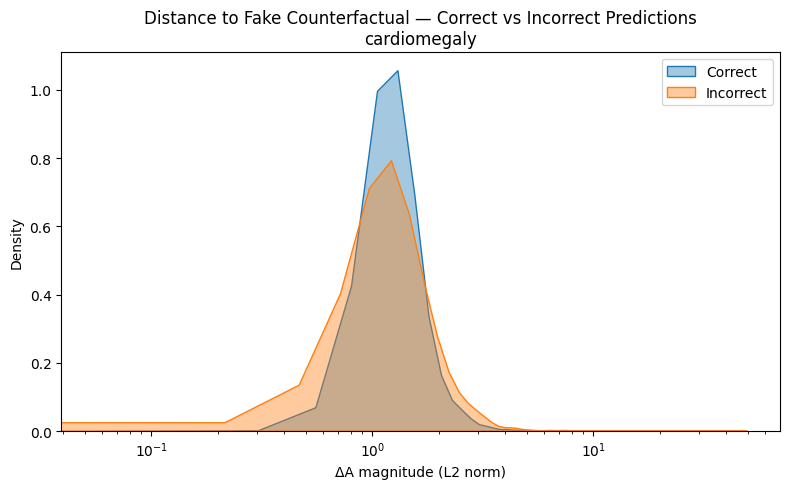

In [77]:
train_dist     = np.linalg.norm(train_diff, axis=1)
correct_mask   = train_filtered['correct'].values == 1

print("Mean ΔA magnitude (L2 norm of difference vector):")
print(f"  Correct predictions   : {train_dist[correct_mask].mean():.4f}")
print(f"  Incorrect predictions : {train_dist[~correct_mask].mean():.4f}")
print(f"  ΔAverage l2 norm of the vectors: {train_dist[correct_mask].mean() - train_dist[~correct_mask].mean():+.4f}")
print()
print("If Correct > Incorrect → the signal is working as hypothesised.")


# Visualise the ΔA magnitude distribution for correct vs incorrect predictions
plt.figure(figsize=(8, 5))
sns.kdeplot(train_dist[correct_mask],   label='Correct',   fill=True, alpha=0.4)
sns.kdeplot(train_dist[~correct_mask],  label='Incorrect', fill=True, alpha=0.4)
plt.xlabel('ΔA magnitude (L2 norm)')
plt.ylabel('Density')
plt.title(f'Distance to Fake Counterfactual — Correct vs Incorrect Predictions\n{DISEASE}')
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.show()

###  Training C2 on the ΔA
- Now we train C2 — the quality control classifier — using ΔA as its features and correct/incorrect as the target.
- Does ΔA add signal BEYOND what C0's confidence already tells us?

In [78]:
# Define the target
y_train = train_filtered['correct'].values
y_valid = valid_filtered['correct'].values

In [79]:
# Reusable train and test so we can use it for the baseline vs the new method

def train_and_eval(X_train, X_valid, y_train, y_valid, label):
    # Scale
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_train)
    X_va_sc  = scaler.transform(X_valid)
    
    # Train Model with balanced setting
    model    = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    
    # Fit the model and predict
    model.fit(X_tr_sc, y_train)
    y_prob   = model.predict_proba(X_va_sc)[:, 1]
    y_pred   = model.predict(X_va_sc)
    
    # Evaluate (ROC and AUC)
    auc_score = roc_auc_score(y_valid, y_prob)
    fpr, tpr, _ = roc_curve(y_valid, y_prob)
    
    # Print results
    print(f"\n{'='*55}")
    print(f"  {label:<47}  AUC = {auc_score:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_valid, y_pred, target_names=['Incorrect', 'Correct']))
    return auc_score, fpr, tpr


In [80]:
train_diff

array([[ 2.38542787e-01, -2.42545689e-01,  4.28997076e-01, ...,
        -2.20514172e-01,  9.39868867e-07, -2.12274416e-01],
       [-1.00107269e+00, -5.65542508e-01,  3.13846393e-01, ...,
        -1.32308503e-01,  5.79581461e-06, -2.99415414e-02],
       [-4.61963508e-01, -5.09590931e-01,  4.17725128e-02, ...,
        -2.64617006e-01,  4.52837479e-06, -6.60841547e-02],
       ...,
       [-6.07867027e-01,  1.95385441e-01, -4.50214860e-01, ...,
         4.41028343e-01, -4.80082204e-06,  1.48480920e-01],
       [-6.24097322e-01,  1.99794874e-02,  8.73023416e-02, ...,
         8.82056687e-02,  2.94173453e-06,  6.35155672e-02],
       [ 2.42887996e-01, -1.17338673e+00, -1.21295000e+00, ...,
         0.00000000e+00,  4.89424356e+01,  3.22322040e-02]])

In [81]:
auc_base, fpr_base, tpr_base = train_and_eval(
    train_filtered[['prob']].values, valid_filtered[['prob']].values,
    y_train, y_valid, "Baseline — C0 prob only"
)

auc_diff, fpr_diff, tpr_diff = train_and_eval(
    train_diff, valid_diff,
    y_train, y_valid, "ΔA only — fake CF difference vector"
)

auc_comb, fpr_comb, tpr_comb = train_and_eval(
    np.hstack([train_filtered[['prob']].values, train_diff]),
    np.hstack([valid_filtered[['prob']].values, valid_diff]),
    y_train, y_valid, "Combined — C0 prob + ΔA"
)


  Baseline — C0 prob only                          AUC = 0.9590
              precision    recall  f1-score   support

   Incorrect       0.80      1.00      0.89        99
     Correct       1.00      0.70      0.83        84

    accuracy                           0.86       183
   macro avg       0.90      0.85      0.86       183
weighted avg       0.89      0.86      0.86       183


  ΔA only — fake CF difference vector              AUC = 0.7155
              precision    recall  f1-score   support

   Incorrect       0.70      0.80      0.75        99
     Correct       0.71      0.60      0.65        84

    accuracy                           0.70       183
   macro avg       0.71      0.70      0.70       183
weighted avg       0.71      0.70      0.70       183


  Combined — C0 prob + ΔA                          AUC = 0.9597
              precision    recall  f1-score   support

   Incorrect       0.80      1.00      0.89        99
     Correct       1.00      0.71      0.8

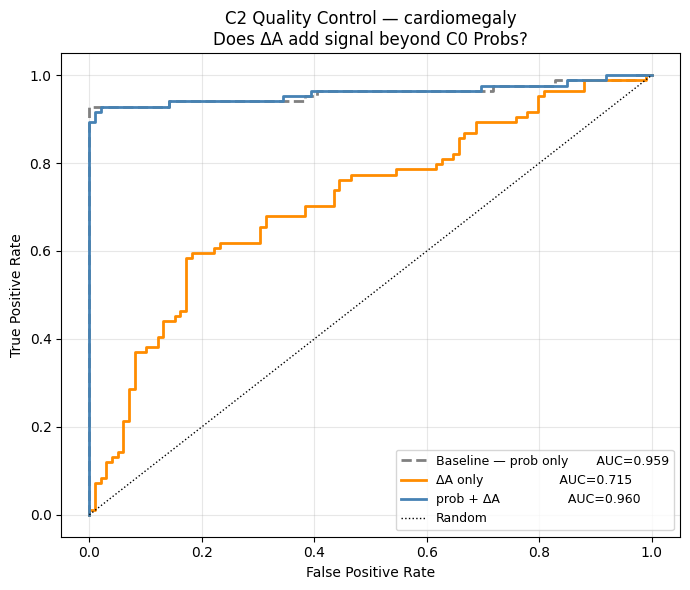

In [82]:
# Plot all three ROC curves together for comparison
plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, color='gray',       lw=2, ls='--', label=f'Baseline — prob only       AUC={auc_base:.3f}')
plt.plot(fpr_diff, tpr_diff, color='darkorange',  lw=2,          label=f'ΔA only                   AUC={auc_diff:.3f}')
plt.plot(fpr_comb, tpr_comb, color='steelblue',   lw=2,          label=f'prob + ΔA                 AUC={auc_comb:.3f}')
plt.plot([0, 1], [0, 1], 'k:', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'C2 Quality Control — {DISEASE}\nDoes ΔA add signal beyond C0 Probs?')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
print(f"Disease        : {DISEASE}")
print(f"Train size     : {len(train_filtered):,}  (correct: {y_train.sum():,} | incorrect: {(1-y_train).sum():,})")
print(f"Valid size     : {len(valid_filtered):,}  (correct: {y_valid.sum():,} | incorrect: {(1-y_valid).sum():,})")
print(f"Features       : {len(relevant_columns)}  {relevant_columns}")
print(f"ΔA shape       : train={train_diff.shape}  valid={valid_diff.shape}")

Disease        : cardiomegaly
Train size     : 11,975  (correct: 9,300 | incorrect: 2,675)
Valid size     : 183  (correct: 84 | incorrect: 99)
Features       : 17  ['cardiothoracic_ratio', 'mediastinal_ratio', 'Heart_area_pixels', 'Heart_bbox_width', 'Heart_bbox_height', 'Heart_bbox_ratio', 'Heart_perimeter', 'Mediastinum_area_pixels', 'Mediastinum_bbox_width', 'Mediastinum_bbox_height', 'Mediastinum_bbox_ratio', 'Mediastinum_perimeter', 'Aorta_area_pixels', 'Aorta_bbox_width', 'Aorta_bbox_height', 'Aorta_bbox_ratio', 'Aorta_perimeter']
ΔA shape       : train=(11975, 17)  valid=(183, 17)


In [84]:
# %%
# Quick test — Random Forest to check if non-linearity helps
from sklearn.ensemble import RandomForestClassifier

def train_and_eval_rf(X_train, X_valid, y_train, y_valid, label):
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_valid)[:, 1]
    auc_score = roc_auc_score(y_valid, y_prob)
    print(f"RF — {label:<45} AUC = {auc_score:.4f}")
    return auc_score

train_and_eval_rf(train_filtered[['prob']].values, valid_filtered[['prob']].values, y_train, y_valid, "Baseline — prob only")
train_and_eval_rf(train_diff, valid_diff, y_train, y_valid, "ΔA only")
train_and_eval_rf(np.hstack([train_filtered[['prob']].values, train_diff]), np.hstack([valid_filtered[['prob']].values, valid_diff]), y_train, y_valid, "Combined — prob + ΔA")

RF — Baseline — prob only                          AUC = 0.8814
RF — ΔA only                                       AUC = 0.7321
RF — Combined — prob + ΔA                          AUC = 0.9653


0.9653078403078403

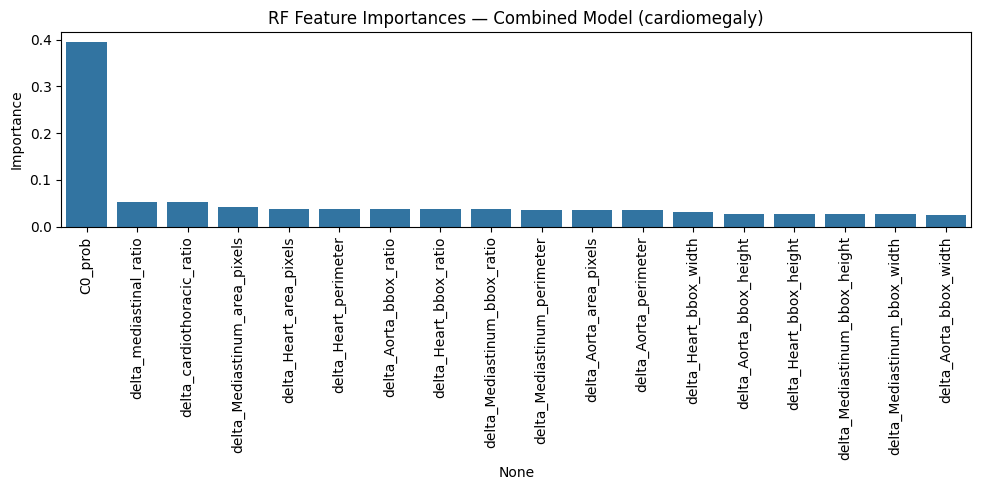

C0_prob                          0.395946
delta_mediastinal_ratio          0.052485
delta_cardiothoracic_ratio       0.052143
delta_Mediastinum_area_pixels    0.041151
delta_Heart_area_pixels          0.038177
delta_Heart_perimeter            0.037701
delta_Aorta_bbox_ratio           0.037271
delta_Heart_bbox_ratio           0.036719
delta_Mediastinum_bbox_ratio     0.036692
delta_Mediastinum_perimeter      0.036300
delta_Aorta_area_pixels          0.035678
delta_Aorta_perimeter            0.035132
delta_Heart_bbox_width           0.031712
delta_Aorta_bbox_height          0.027303
delta_Heart_bbox_height          0.027301
delta_Mediastinum_bbox_height    0.026781
delta_Mediastinum_bbox_width     0.026379
delta_Aorta_bbox_width           0.025128
dtype: float64


In [85]:
# %%
# The combined RF is the strongest model so far.
# Let's look at which attributes are driving it.

X_train_comb = np.hstack([train_filtered[['prob']].values, train_diff])
X_valid_comb = np.hstack([valid_filtered[['prob']].values,  valid_diff])

rf_comb = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_comb.fit(X_train_comb, y_train)

feature_names = ['C0_prob'] + diff_col_names
importances   = pd.Series(rf_comb.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.index, y=importances.values)
plt.xticks(rotation=90)
plt.title(f'RF Feature Importances — Combined Model ({DISEASE})')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(importances)


In [86]:
# %%

def train_and_eval_mlp(X_train, X_valid, y_train, y_valid, label):
    from sklearn.preprocessing import StandardScaler
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_va_sc = scaler.transform(X_valid)
    model   = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
    model.fit(X_tr_sc, y_train)
    y_prob  = model.predict_proba(X_va_sc)[:, 1]
    auc_score = roc_auc_score(y_valid, y_prob)
    print(f"MLP — {label:<45} AUC = {auc_score:.4f}")
    return auc_score

train_and_eval_mlp(train_filtered[['prob']].values, valid_filtered[['prob']].values, y_train, y_valid, "Baseline — prob only")
train_and_eval_mlp(train_diff, valid_diff, y_train, y_valid, "ΔA only")
train_and_eval_mlp(np.hstack([train_filtered[['prob']].values, train_diff]), np.hstack([valid_filtered[['prob']].values, valid_diff]), y_train, y_valid, "Combined — prob + ΔA")

MLP — Baseline — prob only                          AUC = 0.9687
MLP — ΔA only                                       AUC = 0.6996
MLP — Combined — prob + ΔA                          AUC = 0.8937


/zhome/d0/a/221493/thesis/venv/lib64/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


0.8936988936988937